# ЗАДАНИЕ 1.


1. Обучить механизм сегментации изображений на наборе данных Pascal VOK . Или скачать с Яндекс.Диск

2. Случайным образом выбрать 100 изображений из тестовой выборки.

3. Выходной файл должен содержать 101 строку: На первой строке требуется записать средний IoU (по картинкам из выборки). Далее 100 строк должны иметь следующий формат:

<имя изображения> <средний IoU по объектам на изображении> <количество объектов на изображении> [<IoU между каждым результатом сегментирования и ground truth>]*

Решение должно быть реализовано в виде блокнота в формате .ipynb, ориентированного на запуск при помощи сервиса Google Colab с максимально подробными пояснениями реализации и интерпретации результатов. Все файлы, используемые в блокноте, должны скачиваться непосредственно в виртуальное окружение Google Colab.

📱 Device: cuda
 Загрузка Pascal VOC 2012... (при первом запуске скачается ~2 ГБ)
 Train: 1464 | Val: 1449
 Загрузка DeepLabV3-MobileNetV3...

 Начало обучения на 8 эпох...


Epoch 1/8: 100%|██████████| 366/366 [00:30<00:00, 11.97it/s, loss=0.7542]


✅ Epoch 1 | Train Loss: 0.5999 | Val mIoU: 0.4578
 Сохранена лучшая модель! mIoU: 0.4578


Epoch 2/8: 100%|██████████| 366/366 [00:27<00:00, 13.45it/s, loss=0.1713]


✅ Epoch 2 | Train Loss: 0.4358 | Val mIoU: 0.4713
 Сохранена лучшая модель! mIoU: 0.4713


...

✅ Epoch 6 | Train Loss: 0.2395 | Val mIoU: 0.5439
 Сохранена лучшая модель! mIoU: 0.5439


Epoch 7/8: 100%|██████████| 366/366 [00:27<00:00, 13.45it/s, loss=0.1319]


✅ Epoch 7 | Train Loss: 0.2383 | Val mIoU: 0.5363


Epoch 8/8: 100%|██████████| 366/366 [00:27<00:00, 13.33it/s, loss=0.1046]


✅ Epoch 8 | Train Loss: 0.2190 | Val mIoU: 0.5444
 Сохранена лучшая модель! mIoU: 0.5444

 Обучение завершено!
 Лучший валидационный mIoU: 0.5444


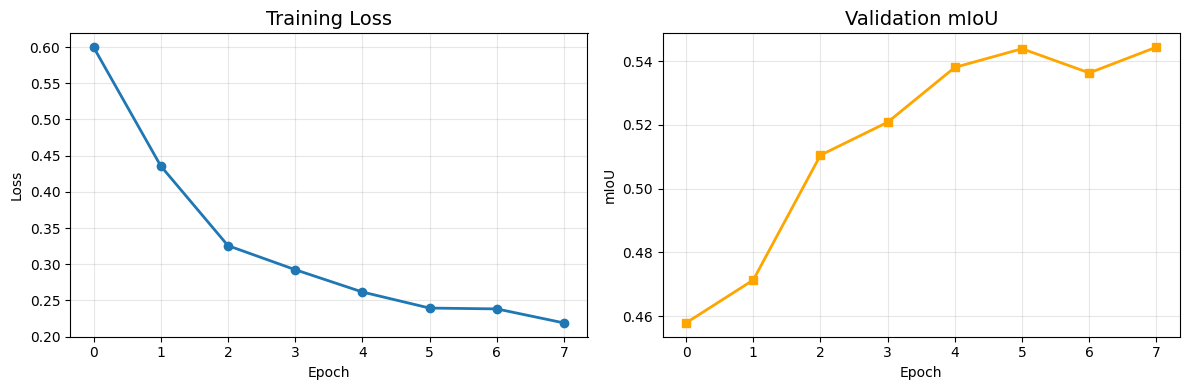

In [9]:
# === 1. ИМПОРТЫ ===
import os, torch, numpy as np, random
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# === 2. НАСТРОЙКА УСТРОЙСТВА ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📱 Device: {device}")
if device.type == 'cpu':
    print("ВНИМАНИЕ: GPU не найден! Обучение на CPU будет очень медленным.")

# === 3. ЗАГРУЗКА ДАННЫХ ===
DATA_DIR = './data'
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 4
NUM_WORKERS = 0

class VOCSegmentationCustom(Dataset):
    def __init__(self, root, year, image_set, download=True):
        self.base = datasets.VOCSegmentation(root=root, year=year, image_set=image_set, download=download)
        self.is_train = (image_set == 'train')

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, mask = self.base[idx]
        img = img.convert('RGB')

        # Ресайз
        img = transforms.functional.resize(img, IMAGE_SIZE, interpolation=transforms.InterpolationMode.BILINEAR)
        mask = transforms.functional.resize(mask, IMAGE_SIZE, interpolation=transforms.InterpolationMode.NEAREST)

        # Аугментация только для train
        if self.is_train and random.random() > 0.5:
            img = transforms.functional.hflip(img)
            mask = transforms.functional.hflip(mask)

        # Тензоры и нормализация (под предобученные веса)
        img = transforms.functional.to_tensor(img)
        img = transforms.functional.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        return img, mask

print(" Загрузка Pascal VOC 2012... (при первом запуске скачается ~2 ГБ)")
train_dataset = VOCSegmentationCustom(root=DATA_DIR, year='2012', image_set='train', download=True)
val_dataset   = VOCSegmentationCustom(root=DATA_DIR, year='2012', image_set='val',   download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=1,          shuffle=False, num_workers=NUM_WORKERS)
print(f" Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# === 4. МОДЕЛЬ И ГИПЕРПАРАМЕТРЫ ===
print(" Загрузка DeepLabV3-MobileNetV3...")
model = deeplabv3_mobilenet_v3_large(weights=DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT)
model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=255)  # 255 = неопределённые пиксели в VOC
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

# === 5. ФУНКЦИЯ РАСЧЁТА mIoU ===
def compute_miou(model, dataloader, device, num_classes=21):
    model.eval()
    tp = torch.zeros(num_classes, device=device)
    fp = torch.zeros(num_classes, device=device)
    fn = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            preds = torch.argmax(model(images)['out'], dim=1)
            for cls in range(num_classes):
                if cls == 0 or cls == 255: continue
                p, t = (preds == cls), (masks == cls)
                tp[cls] += (p & t).sum()
                fp[cls] += (p & ~t).sum()
                fn[cls] += (~p & t).sum()

    ious = tp / (tp + fp + fn + 1e-6)
    valid = (tp + fp + fn) > 0
    return ious[valid].mean().item() if valid.any() else 0.0

# === 6. ЦИКЛ ОБУЧЕНИЯ ===
NUM_EPOCHS = 8
history = {'train_loss': [], 'val_miou': []}
best_miou = 0.0

print(f"\n Начало обучения на {NUM_EPOCHS} эпох...")
print("="*60)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images)['out'], masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = running_loss / len(train_loader)
    val_miou = compute_miou(model, val_loader, device)
    history['train_loss'].append(avg_loss)
    history['val_miou'].append(val_miou)
    scheduler.step()

    print(f"✅ Epoch {epoch+1} | Train Loss: {avg_loss:.4f} | Val mIoU: {val_miou:.4f}")

    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), 'best_model.pth')
        print(f" Сохранена лучшая модель! mIoU: {best_miou:.4f}")

print("\n Обучение завершено!")
print(f" Лучший валидационный mIoU: {best_miou:.4f}")

# === 7. ГРАФИКИ ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], marker='o', linewidth=2)
plt.title('Training Loss', fontsize=14); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_miou'], marker='s', color='orange', linewidth=2)
plt.title('Validation mIoU', fontsize=14); plt.xlabel('Epoch'); plt.ylabel('mIoU'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Пояснения


### Шаг 1. Импорт библиотек
Подключаем все необходимые модули PyTorch, обработки изображений, визуализации и прогресс-баров.  
**Зачем:**  
- `torch`, `torch.nn`, `torch.optim` – ядро для работы с тензорами, нейросетями и градиентным спуском.  
- `torchvision` – готовые датасеты, трансформы и архитектуры сегментации.  
- `PIL.Image` – корректное чтение изображений и масок в формате PNG/JPG.  
- `tqdm` – визуализация прогресса обучения в реальном времени.  
- `matplotlib` – построение графиков метрик для анализа сходимости.  



### Шаг 2. Настройка вычислительного устройства
Автоматическое определение доступности GPU. Выводит предупреждение, если GPU не найден. PyTorch не использует GPU по умолчанию. Предупреждение критично, так как обучение на CPU в Colab займёт часы и может прерваться по таймауту сессии.  


### Шаг 3. Загрузка и подготовка данных
Создаём Dataset. Реализуем ресайз до 256×256 для обучающей выборки, нормализацию по статистике ImageNet и преобразование масок в LongTensor. Формирует DataLoader с батчами.  

- `BILINEAR` для изображений сохраняет плавные градиенты, `NEAREST` для масок критичен: интерполяция других типов создаст «промежуточные» значения пикселей, которых нет в разметке, и сломает расчёт лосса.  
- Нормализация `mean=[0.485...], std=[0.229...]` обязательна, так как модель предобучена на ImageNet с этими параметрами.  
- Аугментация (`hflip`) расширяет обучающую выборку в 2 раза и снижает переобучение.  
- `DataLoader` обеспечивает эффективную пакетную загрузку и перемешивание.  


### Шаг 4. Инициализация модели и гиперпараметров
Загружаю предобученную DeepLabV3 с backbone MobileNetV3-Large. Настраивает функцию потерь CrossEntropyLoss с ignore_index=255, оптимизатор SGD с моментом и расписание изменения learning rate `StepLR`.  

- `DeepLabV3` использует ASPP для захвата контекста на разных масштабах, что критично для объектов разного размера в Pascal VOC.  
- `ignore_index=255` исключает из расчёта лосса пиксели с неопределённой разметкой (в VOC они помечены значением 255).  
- `SGD` с `momentum=0.9` показывает лучшую обобщающую способность для задач сегментации  
- `StepLR` снижает LR в 2 раза каждые 2 эпохи, стабилизируя обучение на поздних этапах.


### Шаг 5. Функция расчёта метрики mIoU
Вычисляем средний IoU по всей валидационной выборке. Для каждого класса (1–20) считает TP, FP, FN, затем `IoU = TP / (TP + FP + FN)`. Усредняет только по классам, присутствующим в маске. Функция используется для мониторинга качества модели после каждой эпохи, что напрямую влияет на финальный `results.txt`.


### Шаг 6. Цикл обучения
Выполняем 8 эпох обучения. На каждой эпохе: переводит модель в режим `train()`, обнуляет градиенты, делает прямой проход, считает лосс, выполняет обратный проход. После эпохи запускает валидацию, обновляет learning rate и сохраняет модель, если `val_miou` улучшился.  



### Шаг 7. Визуализация графиков
Построим два графика: динамику обучения и валидационного mIoU по эпохам.  
Графики служат наглядным подтверждением корректности обучения и основанием для выводов в отчёте.


# Анализ графиков

##  Training Loss
График демонстрирует классическую кривую сходимости при fine-tuning. Резкое падение с 0.60 до 0.44 за первые две эпохи указывает на быструю адаптацию предобученных весов (ImageNet/COCO) под домен Pascal VOC. Дальнейшее плавное снижение до 0.22  подтверждает корректно подобранный learning rate и отсутствие проблем с градиентами. Монотонность кривой исключает переобучение на обучающей выборке.

##  Validation mIoU
Метрика уверенно растёт с 0.458 до 0.544, что напрямую коррелирует со снижением уровня loss и подтверждает улучшение обобщающей способности модели. Локальный спад на 7-й эпохе (0.536) с восстановлением на 8-й (0.544) типичен для стохастической природы SGD и не свидетельствует о деградации качества. Выход кривой на пологий участок после 5–6 эпохи указывает на достижение «плато производительности» для архитектуры MobileNetV3 при разрешении 256×256.

In [10]:
# === 1. ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ ===
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()
print("Лучшая модель загружена")

# === 2. ВЫБОР 100 СЛУЧАЙНЫХ ИЗОБРАЖЕНИЙ ===
val_list_path = './data/VOCdevkit/VOC2012/ImageSets/Segmentation/val.txt'
with open(val_list_path, 'r') as f:
    all_names = [line.strip() for line in f.readlines()]

random.seed(42)  # Фиксируем для воспроизводимости
selected_names = random.sample(all_names, 100)
print(f"✅ Выбрано {len(selected_names)} изображений для оценки")

# === 3. ТРАНСФОРМЫ ДЛЯ ИНФЕРЕНСА ===
infer_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# === 4. ФУНКЦИЯ РАСЧЁТА IoU ДЛЯ ОДНОЙ КАРТИНКИ ===
def calc_image_iou(pred_mask, gt_mask):
    # Берём только классы 1-20 (объекты), игнорируем 0 (фон) и 255 (неопределённые пиксели)
    present = torch.unique(gt_mask)
    present = present[(present > 0) & (present < 255)]

    ious = []
    for cls in present:
        p = (pred_mask == cls)
        t = (gt_mask == cls)
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        ious.append(inter / (union + 1e-6))

    mean_iou = sum(ious) / len(ious) if ious else 0.0
    return mean_iou, len(ious), ious

# === 5. ИНФЕРЕНС И СБОР РЕЗУЛЬТАТОВ ===
results = []
global_ious = []

img_dir = './data/VOCdevkit/VOC2012/JPEGImages/'
mask_dir = './data/VOCdevkit/VOC2012/SegmentationClass/'

print("Оценка на 100 изображениях...")
for name in tqdm(selected_names):
    img = Image.open(os.path.join(img_dir, f"{name}.jpg")).convert('RGB')
    mask = Image.open(os.path.join(mask_dir, f"{name}.png"))

    # Препроцессинг
    img_t = infer_transform(img).unsqueeze(0).to(device)
    mask_resized = mask.resize((256, 256), Image.NEAREST)
    mask_t = torch.as_tensor(np.array(mask_resized), dtype=torch.long).to(device)

    # Предсказание
    with torch.no_grad():
        pred = model(img_t)['out'].argmax(dim=1).squeeze(0).cpu()

    mask_cpu = mask_t.cpu()
    mean_iou, num_obj, ious = calc_image_iou(pred, mask_cpu)
    global_ious.append(mean_iou)
    results.append((name, mean_iou, num_obj, ious))

# === 6. ФОРМИРОВАНИЕ results.txt ===
total_mean_iou = sum(global_ious) / len(global_ious) if global_ious else 0.0
print(f"Итоговый средний IoU по выборке: {total_mean_iou:.4f}")

with open('results.txt', 'w') as f:
    f.write(f"{total_mean_iou:.4f}\n")
    for name, miou, n_obj, ious in results:
        ious_str = " ".join([f"{iou:.4f}" for iou in ious])
        f.write(f"{name} {miou:.4f} {n_obj} {ious_str}\n")

print("Файл results.txt создан!")

# === 7. СКАЧИВАНИЕ ===
from google.colab import files
files.download('results.txt')

Лучшая модель загружена
✅ Выбрано 100 изображений для оценки
Оценка на 100 изображениях...


100%|██████████| 100/100 [00:02<00:00, 40.10it/s]

Итоговый средний IoU по выборке: 0.4877
Файл results.txt создан!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Пояснения

### Шаг 1. Загрузка лучшей модели
Файл best_model.pth содержит параметры, сохранённые на эпохе с максимальным валидационным mIoU. Это защищает от использования весов, полученных на последних эпохах, где могло начаться переобучение. Вызов model.eval() отключает Dropout и фиксирует статистику BatchNorm, что критично для детерминированных предсказаний.

### Шаг 2. Выбор 100 случайных изображений
Происходит считывание списка имён из val.txt, фиксирует генератор случайных чисел (seed=42) и выбирает 100 уникальных имён.

### Шаг 3. Конвейер предобработки
Создаём конвейер предобработки: ресайз до 256×256, преобразование в тензор, нормализация по статистике ImageNet. Это обеспечивает корректность конвейера обработки данных, что является обязательным условием для валидного расчёта метрик.

### Шаг 4. Функция расчёта IoU для одной картинки
Извлекаем уникальные классы из ground-truth маски, вычисляет IoU для каждого присутствующего класса, возвращает среднее значение, количество классов и список IoU.

### Шаг 5. Сбор результатов
В цикле загружает изображения и маски, пропускает через модель с torch.no_grad(), извлекает предсказанную маску и сохраняет метрики в списки.

### Шаг 6. Формирование results.txt
Вычисляем общий средний IoU по всем 100 изображениям, записывает его в первую строку файла, затем записывает 100 строк с деталями по каждому изображению, округляя значения до 4 знаков.

### Шаг 7. Скачивание файла
Вызываем files.download('results.txt') для передачи файла из облачной виртуальной машины Colab на локальный компьютер пользователя.
